In [1]:
import numpy as np
from os.path import join
import matplotlib.pyplot as plt

In [2]:
parent_path = '/data/cschmidt/excited_states/energy_apply_NNs/all_solvents'
prefix = 'nn_input_'

solvent_names = ['acn', 'methanol', 'dcm', 'dmso', 'water', 'acetone']

In [3]:
solvent_file_names = [prefix + solvent_name + '.dat' for solvent_name in solvent_names]
solvent_paths = [join(parent_path, solvent_file_name) for solvent_file_name in solvent_file_names]

Histogram for ESP - water
-0.0008675629274078501
0.006878967280998151


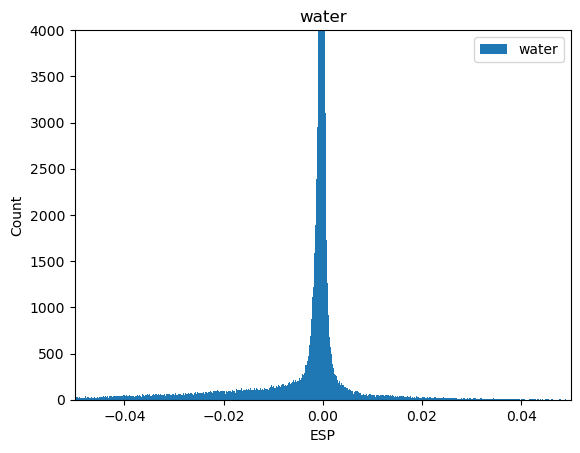

In [28]:
hist_datas = {}
for solvent_path, solvent_name in zip(solvent_paths, solvent_names):
    if solvent_name != 'water':
        continue
    solvent_data = np.loadtxt(solvent_path, usecols=(4))
    print(f'Histogram for ESP - {solvent_name}')
    print(np.mean(solvent_data, axis=0))
    print(np.std(solvent_data, axis=0))
    hist_data = plt.hist(solvent_data, bins=10000, label=solvent_name)
    hist_datas[solvent_name] = hist_data

    plt.title(f'{solvent_name}')
    plt.xlim(-0.05, 0.05)
    plt.ylim(0, 4000)
    plt.xlabel("ESP")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [12]:
water_hist = hist_datas['water']

In [23]:
edges_smaller_than_value = 0
threshold_value = -0.05
for value, edge in zip(water_hist[0], water_hist[1]):
    # print(f'{edge} {value}')
    if edge < threshold_value:
        print(f'{edge} {value}')
        edges_smaller_than_value += value

total_values = np.sum(water_hist[0])
print(f'Edges smaller than {threshold_value}: {edges_smaller_than_value}')
print(f'Total values: {total_values}')
print(f'Fraction of values smaller than {threshold_value}: {round(edges_smaller_than_value / total_values * 100, 2)}%')

-0.200516 4.0
-0.18576209999999999 8.0
-0.1710082 28.0
-0.1562543 132.0
-0.1415004 280.0
-0.12674649999999998 614.0
-0.1119926 1271.0
-0.0972387 2034.0
-0.0824848 2955.0
-0.06773090000000001 5996.0
-0.052976999999999996 14854.0
Edges smaller than -0.05: 28176.0
Total values: 3600045.0
Fraction of values smaller than -0.05: 0.78%


In [44]:
new_parent_path = '/data/cschmidt/excited_states/data_energy/train_h2o_exc_s1mixed_osc_retry.dat'

ESP = []
natoms = 45

import subprocess
# get number of molecules
result = subprocess.run(['wc', '-l', new_parent_path], capture_output=True, text=True)
print(result)
max_n_molecules = int(result.stdout.split()[0])
max_n_molecules /= natoms + 1
max_n_molecules = int(max_n_molecules)
print(f"Max len is {max_n_molecules}")

with open(new_parent_path,"r") as data:
    for i in range(max_n_molecules):
        data.readline()
        for j in range(natoms):
            line = data.readline()
            # print(f"i ist {i}; j it {j} line ist \n{line}")
            # print(i)
            try:
                ESP.append(np.float64(line.split()[4]))
            except:
                print(f"The line is {line}")
                print(i, i*(natoms + 2) +j)
                raise ValueError("Error")
        data.readline()

print(f'Histogram for ESP - {solvent_name}')
print(np.mean(solvent_data, axis=0))
print(np.std(solvent_data, axis=0))
hist_data = plt.hist(solvent_data, bins=100, label=solvent_name)

plt.title(f'Training Data')
# plt.xlim(-0.05, 0.05)
# plt.ylim(0, 4000)
plt.xlabel("ESP")
plt.ylabel("Count")
plt.legend()
plt.show()

CompletedProcess(args=['wc', '-l', '/data/cschmidt/excited_states/data_energy/train_h2o_exc_s1mixed_osc_retry.dat'], returncode=0, stdout='14194 /data/cschmidt/excited_states/data_energy/train_h2o_exc_s1mixed_osc_retry.dat\n', stderr='')
Max len is 308
The line is 
302 14194


ValueError: Error